# Foundation: figure 1<->* axes 


**Die Hierarchie:**

```
Figure (die gesamte Zeichenfläche)
  └── Axes (der Plotbereich mit x/y-Achsen)
       ├── x-Achse
       ├── y-Achse
       └── Plot-Elemente (Linien, Punkte, etc.)
```

**Wichtig zu verstehen:**

- **Figure** = Das gesamte Fenster/Bild (wie ein Blatt Papier)
- **Axes** = Der eigentliche Plot-Bereich (wie ein Koordinatensystem auf dem Papier)
- Eine Figure kann mehrere Axes enthalten (Subplots)
- Axes ist NICHT die Achse (axis), sondern der gesamte Plot-Bereich und Chart!


## Object-oriented

The next level down in the matplotlib hierarchy is the object-oriented (OO) interface to produce figures.

The main idea with OO programming is to have objects that one can apply functions and actions on, and no object or program states should be global (such as the MATLAB-like interface). The real advantage of this approach becomes apparent when more than one figure is created, or when a figure contains more than one subplot - more about that later.

At this level, the user creates most of the time figures with `pyplot`, and through those figures, one or more "axes" objects can be created. These axes objects are then used for most plotting actions.

We use now the OO interface: instead of creating a new global figure instance we store a reference to the newly created figure instance in the `fig` variable, and from it we create a new axis instance using the `add_axes` method:

### Figure

Everything in matplotlib lives within a `Figure` object.

The figure keeps track of all the child Axes, a group of special "Artists" (titles, figure legends, etc), nested subfigures, and the canvas.

A figure can have any number of Axes (at least one, to be useful).

| Attribut | Returns |
|----------|---------|
| `.axes` | `[Axes, ...]` |
| `.texts` | `[Text, ...]` |
| `.patches` | `[Patch, ...]` |
| `.lines` | `[Line2D, ...]` |
| `.images` | `[AxesImage, ...]` |
| `.legends` | `[Legend, ...]` |
| **Property** | **Returns** |
| `facecolor` | color |
| `edgecolor` | color |
| `figwidth` / `figheight` | float (inches) |
| `dpi` | float |
| `frameon` | bool |
| `suptitle` | → Text |

You can think of the figure object as a canvas that holds all the subplots and other plot elements inside it.

In [32]:
print([k for k in vars(fig).keys() if not k.startswith('_')])

for name, obj in [("fig", fig)]:
    print(f"\n=== {name} ===")
    plt.setp(obj)

print(f"\nFigure Größe: {fig.get_size_inches()} inches")
print(f"Axes Position: {ax.get_position()}")

['stale_callback', 'figure', 'clipbox', 'artists', 'lines', 'patches', 'texts', 'images', 'legends', 'subfigs', 'suppressComposite', 'bbox_inches', 'dpi_scale_trans', 'bbox', 'figbbox', 'transFigure', 'transSubfigure', 'patch', 'canvas', 'subplotpars', 'number']

=== fig ===
  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  canvas: FigureCanvas
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  constrained_layout: unknown
  constrained_layout_pads: unknown
  dpi: float
  edgecolor: :mpltype:`color`
  facecolor: :mpltype:`color`
  figheight: float
  figure: `~matplotlib.figure.Figure`
  figwidth: float
  frameon: bool
  gid: str
  in_layout: bool
  label: object
  layout_engine: {'constrained', 'compressed', 'tight', 'none', `.LayoutEngine`, None}
  linewi

**OO Way todo it**

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html

--------------
### .subplots - Häufigste Weg um Axes/Charts zu definieren

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html

Die Axes werden als Tupeln gegeben (wenn 2,2 ist es ähnlich zu einer Matrize)
![](https://matplotlib.org/stable/_images/sphx_glr_arranging_axes_002_2_00x.png)

mit GridSpec ist es ähnlich (https://matplotlib.org/stable/users/explain/axes/arranging_axes.html); am besten man ordnet jedem ax{0-3} eine Variable zu

![](https://matplotlib.org/stable/_images/sphx_glr_arranging_axes_010_2_00x.png)

If we don't care about specifying where the plot axes are placed in the figure canvas, then we can use one of the many axis layout managers in matplotlib. My favorite is `subplots`, which can be used like this:

Text(0.5, 0.98, 'Figure title')

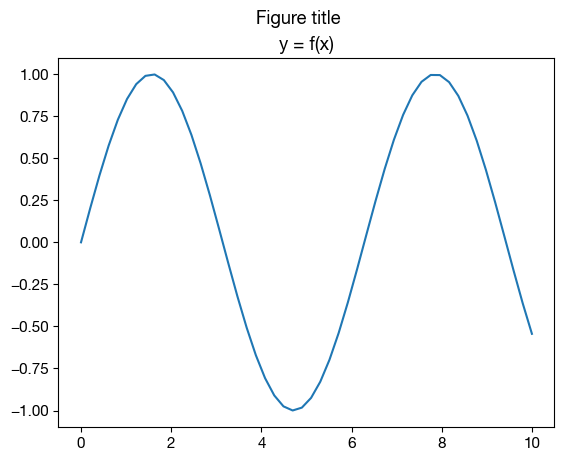

In [127]:
x = np.linspace(0, 10, 50)
y = np.sin(x)

fig, ax = plt.subplots()

ax.plot(x, y)
#ax.set_xlabel('x')
#ax.set_ylabel('y')
ax.set_title('y = f(x)') # this is the axis title
fig.suptitle("Figure title") # this is the figure title

Axes(0.125,0.11;0.775x0.77)


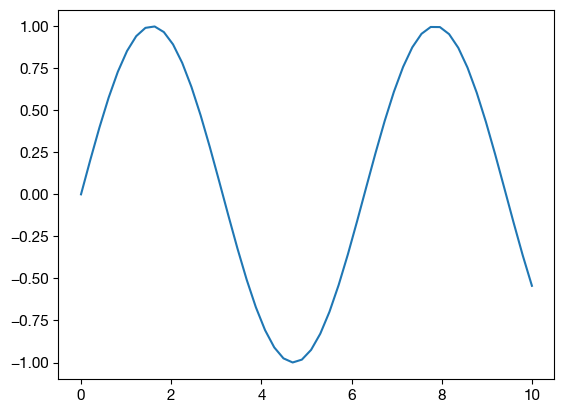

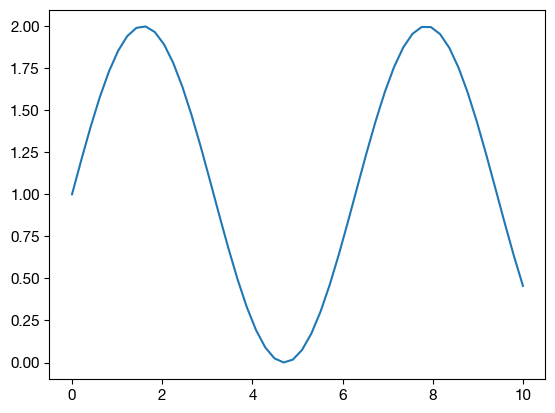

In [92]:
# Easier and more robust going forward (what we're going to use) # Standard
fig, ax = plt.subplots(1,1) #plot = figure ; charts = axes
#ax = fit.add_subplot(1,1,1), nicht gemacht
ax.plot(x, y);
print(ax)

# How to draw 2 scatteplots in different panels
fig, ax2 = plt.subplots()
ax2.plot(x, y+[1 for i in range(len(y))]);

### .add_subplot()

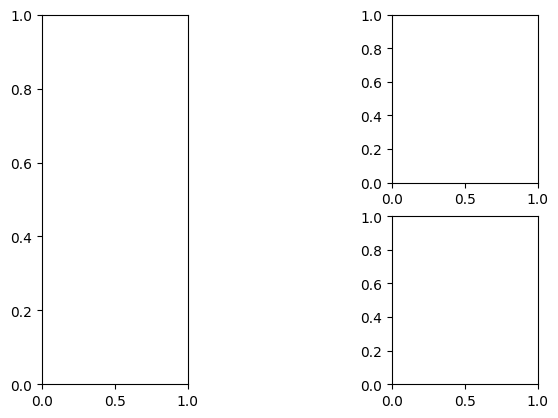

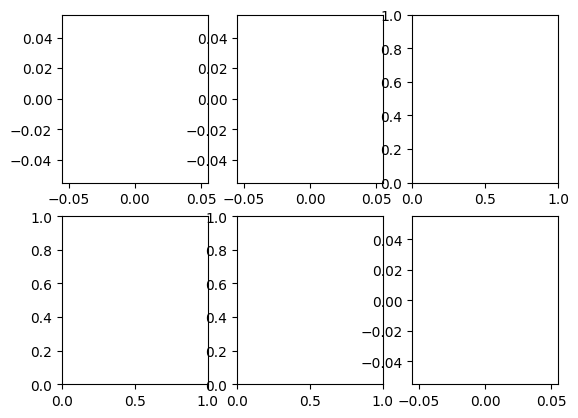

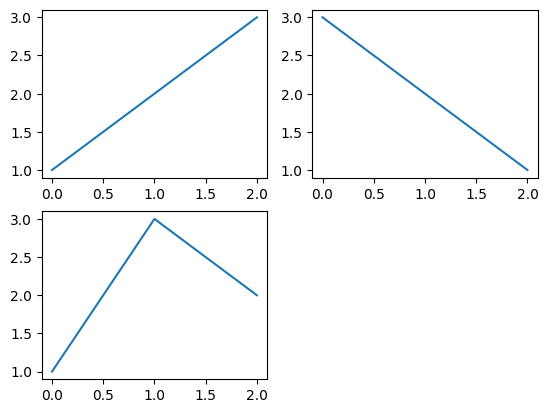

In [33]:
# Creating a plot with the OO verison, confusing way first; 
# #Ihr werdet sowas vielleicht sehen, aber es ist 
# äquivalent zu fig, ax = plt.subplots() und obrigem

from typing import Any

fig = plt.figure()

# add_subplot(nrows, ncols, index)
#
# nrows = wie viele ZEILEN im grid
# ncols = wie viele SPALTEN im grid
# index = position, zählt durch wie lesen: →, dann nächste zeile
#
# ACHTUNG: jeder ax definiert sein EIGENES grid relativ zur ganzen figure!
#
# ax1: grid (1,3) → 1 zeile, 3 spalten
#  [ 1 ][ 2 ][ 3 ]
#   ↑
#   ax1 = position 1 → linkes drittel, VOLLE höhe (weil nur 1 zeile)
#
# ax2 + ax3: grid (2,3) → 2 zeilen, 3 spalten
#  [ 1 ][ 2 ][ 3 ]
#  [ 4 ][ 5 ][ 6 ]
#          ↑     ↑
#          ax2=3  ax3=6 → beide in spalte 3, ax2 oben, ax3 unten
#
# ergebnis:
# ┌──────────┬──────┬──────┐
# │          │      │  ax2 │
# │   ax1    ├──────┼──────┤
# │          │      │  ax3 │
# └──────────┴──────┴──────┘

ax1: Any = fig.add_subplot(1, 3, 1)  # 1 Zeile,  3 Spalten, Position 1 → links, volle Höhe
ax2: Any = fig.add_subplot(2, 3, 3)  # 2 Zeilen, 3 Spalten, Position 3 → oben rechts
ax3: Any = fig.add_subplot(2, 3, 6)  # 2 Zeilen, 3 Spalten, Position 6 → unten rechts

plt.show()

# ---

# äquivalent aber kürzer — gibt numpy array von Axes zurück
fig, axes = plt.subplots(2, 3)  # 2 Zeilen, 3 Spalten

axes[0, 0].plot()  # Zeile 0, Spalte 0
axes[0, 1].plot()  # Zeile 0, Spalte 1
axes[1, 2].plot()  # Zeile 1, Spalte 2

plt.show()

fig: Any = plt.figure()

ax1: Any = fig.add_subplot(2, 2, 1)  # oben links
ax2: Any = fig.add_subplot(2, 2, 2)  # oben rechts
ax3: Any = fig.add_subplot(2, 2, 3)  # unten links
# 4 bleibt leer — einfach nicht hinzufügen

ax1.plot([1,2,3])
ax2.plot([3,2,1])
ax3.plot([1,3,2])

plt.show()

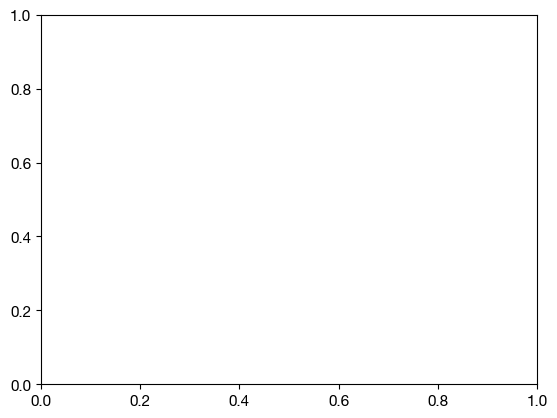

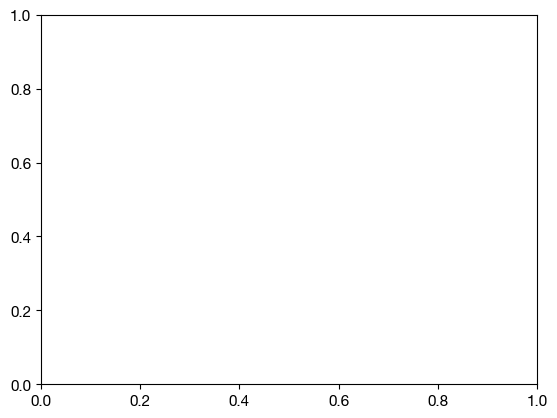

In [93]:
# ── 3 Wege eine Figure zu erstellen ──────────────────────────────────────────

# 1. pyplot — nur figure, noch keine axes
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)  # axes muss man selbst hinzufügen

# 2. pyplot — figure + axes auf einmal (Standard, 95% der Fälle)
fig, ax = plt.subplots()

# 3. pure OO — kein pyplot, kein globaler state
#    wird benutzt in web/GUI apps, nicht in Jupyter
from matplotlib.figure import Figure
fig = Figure()
ax = fig.add_subplot(1, 1, 1)

# ─────────────────────────────────────────────────────────────────────────────
# alle drei geben dasselbe: ein Figure objekt mit einem Axes objekt
# der unterschied ist nur wer den globalen state (plt.gcf / plt.gca) verwaltet
#
#  plt.figure()   →  figure wird in pyplot globalem state registriert
#  plt.subplots() →  figure wird in pyplot globalem state registriert
#  Figure()       →  kein pyplot, kein globaler state — du bist allein verantwortlich

### .add_axes()

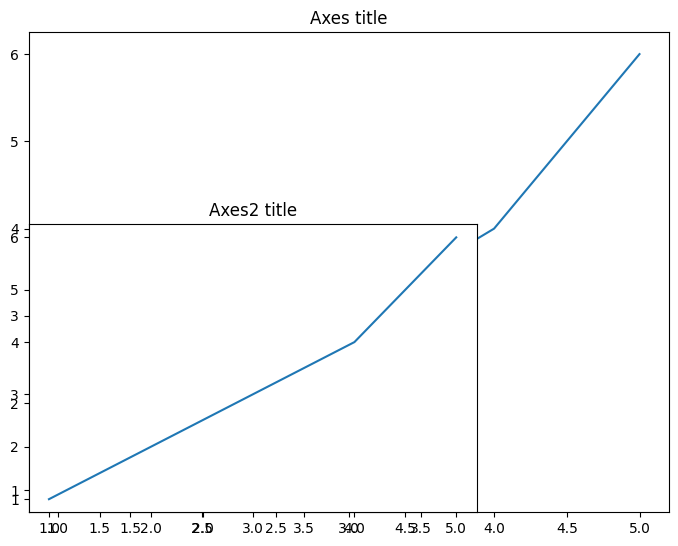

In [34]:
# Confusing #2 - besser als #1 - das hilft aber um charts später zu überlappen 
fig = plt.figure()


ax = fig.add_axes([1,1    ,1,1])
ax.plot(x, y)
ax.set_title("Axes title")

                        
ax2 = fig.add_axes([1,1    ,0.7,0.6])
 # 4 indizes: (Richtung es platziert wird) : x, y
ax2.plot(x, y)
ax2.set_title("Axes2 title")

plt.show()

In [35]:
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # left, bottom, width, height (range 0-1)

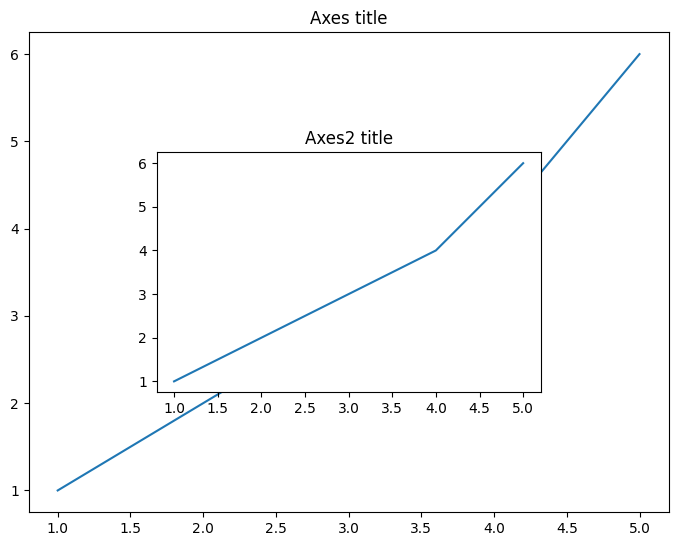

In [36]:
# Confusing #2 - besser als #1 - das hilft aber um charts später zu überlappen 
fig = plt.figure()

ax = fig.add_axes([0.8,1,         1,1])
ax.plot(x, y)
ax.set_title("Axes title")

                              #Größe der Chart zu tun
ax2 = fig.add_axes([1, 1.25,     0.6, 0.5]) # aufeinander
 # 4 indizes: (Richtung es platziert wird) : x, y,        width, height
ax2.plot(x, y)
ax2.set_title("Axes2 title")

plt.show()

Although a little bit more code is involved, the advantage is that we now have full control of where the plot axes are placed, and we can easily add more than one axis to the figure:

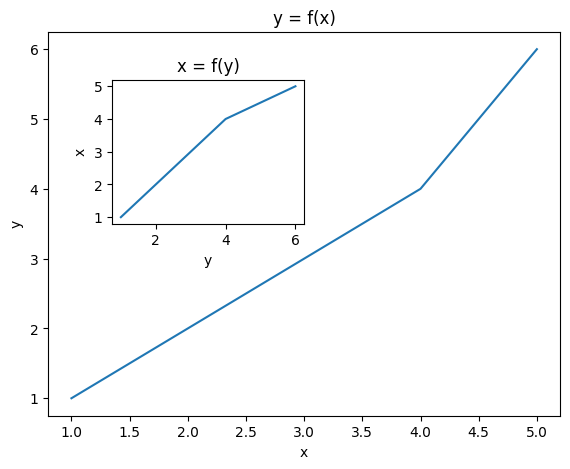

In [37]:
fig = plt.figure()

axes1 = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # main axes
axes2 = fig.add_axes([0.2, 0.5, 0.3, 0.3]) # inset axes

# main figure
axes1.plot(x, y)
axes1.set_xlabel('x')
axes1.set_ylabel('y')
axes1.set_title('y = f(x)')

# inset
axes2.plot(y, x)
axes2.set_xlabel('y')
axes2.set_ylabel('x')
axes2.set_title('x = f(y)');